# UC_AVM — Exploratory Data Analysis
Visualize raw and cleaned distributions to identify preprocessing improvements.

In [1]:
import sys
import sqlite3
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.insert(0, str(Path('.').resolve()))
from train import load_data, DB_PATH
from features import NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET, ALL_FEATURES

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
FIG_W = 14
TOP_N = 15

# Raw: direct DB read, no cleaning
conn = sqlite3.connect(DB_PATH)
df_raw = pd.read_sql_query('SELECT * FROM listings', conn)
conn.close()

# Clean: full pipeline (currency fix + IQR filter)
df_clean = load_data(DB_PATH)

print(f'Raw rows : {len(df_raw):,}')
print(f'Clean rows (after IQR filter): {len(df_clean):,}')
print(f'Dropped  : {len(df_raw) - len(df_clean):,}')

INFO: Corrected 9680 mislabeled currency rows


INFO: Converted 10794 ARS prices to USD (rate: 1 USD = 1400 ARS)


INFO: IQR filter: removed 922 outliers (bounds: $-12857 – $50000)


INFO: Loaded 16952 rows (17 features)


Raw rows : 18,328
Clean rows (after IQR filter): 16,952
Dropped  : 1,376


## 1. Raw Data Overview

In [2]:
null_summary = pd.DataFrame({
    'dtype'   : df_raw.dtypes,
    'nulls'   : df_raw.isnull().sum(),
    'null_%'  : (df_raw.isnull().mean() * 100).round(1),
    'unique'  : df_raw.nunique(),
}).sort_values('null_%', ascending=False)

print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns\n')
null_summary

Shape: 18,328 rows × 25 columns



,dtype,nulls,null_%,unique
moneda,str,10112,55.2,2
es_concesionario,float64,6919,37.8,2
provincia,str,5786,31.6,47
trim_level,str,2427,13.2,794
cilindrada_cc,float64,1336,7.3,106
marca,str,990,5.4,95
tipo_carroceria,str,932,5.1,34
traccion,str,747,4.1,16
modelo,str,639,3.5,908
transmision,str,608,3.3,13


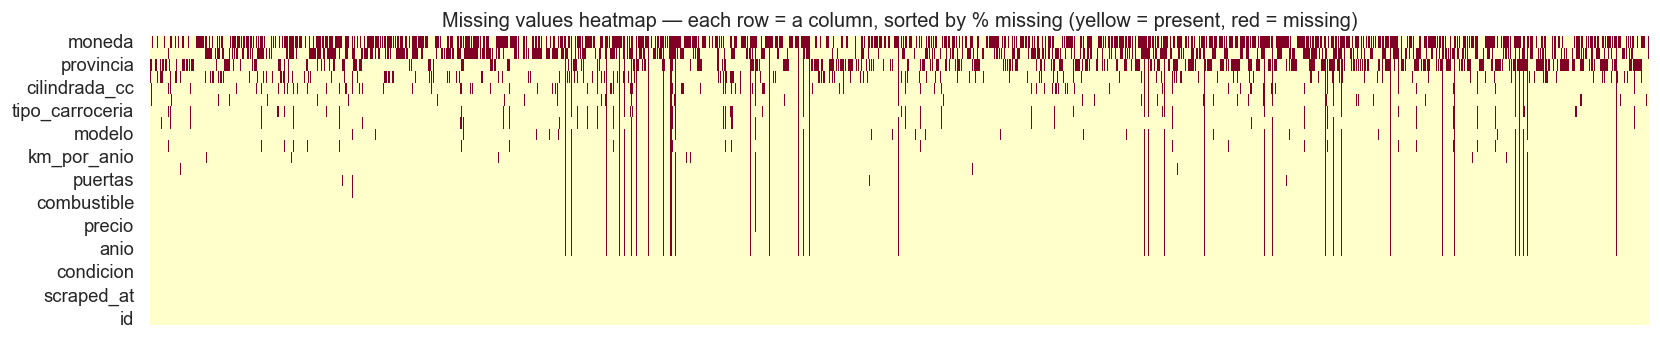

In [3]:
# Null heatmap — columns sorted by % missing
col_order = null_summary.index.tolist()
fig, ax = plt.subplots(figsize=(FIG_W, 3))
sns.heatmap(
    df_raw[col_order].isnull().T,
    cbar=False, cmap='YlOrRd', ax=ax, xticklabels=False
)
ax.set_title('Missing values heatmap — each row = a column, sorted by % missing (yellow = present, red = missing)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 2. Price & Currency Analysis

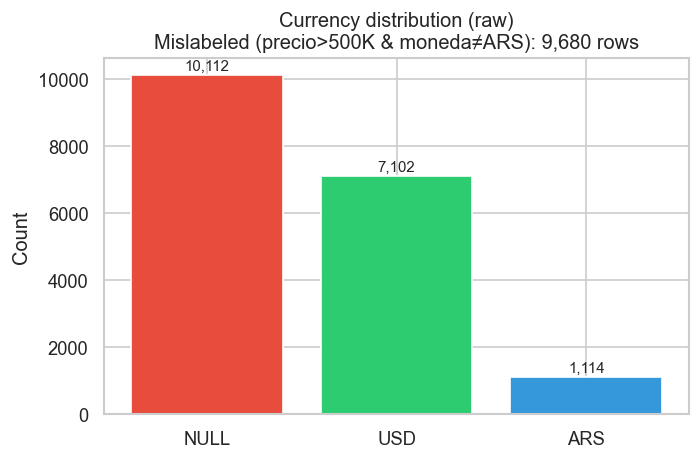

In [4]:
# Currency distribution
currency_counts = df_raw['moneda'].fillna('NULL').value_counts()
mislabeled = int(((df_raw['precio'] > 500_000) & (df_raw['moneda'] != 'ARS')).sum())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(currency_counts.index, currency_counts.values,
              color=['#e74c3c', '#2ecc71', '#3498db'][:len(currency_counts)])
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
ax.set_title(f'Currency distribution (raw)\nMislabeled (precio>500K & moneda≠ARS): {mislabeled:,} rows')
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

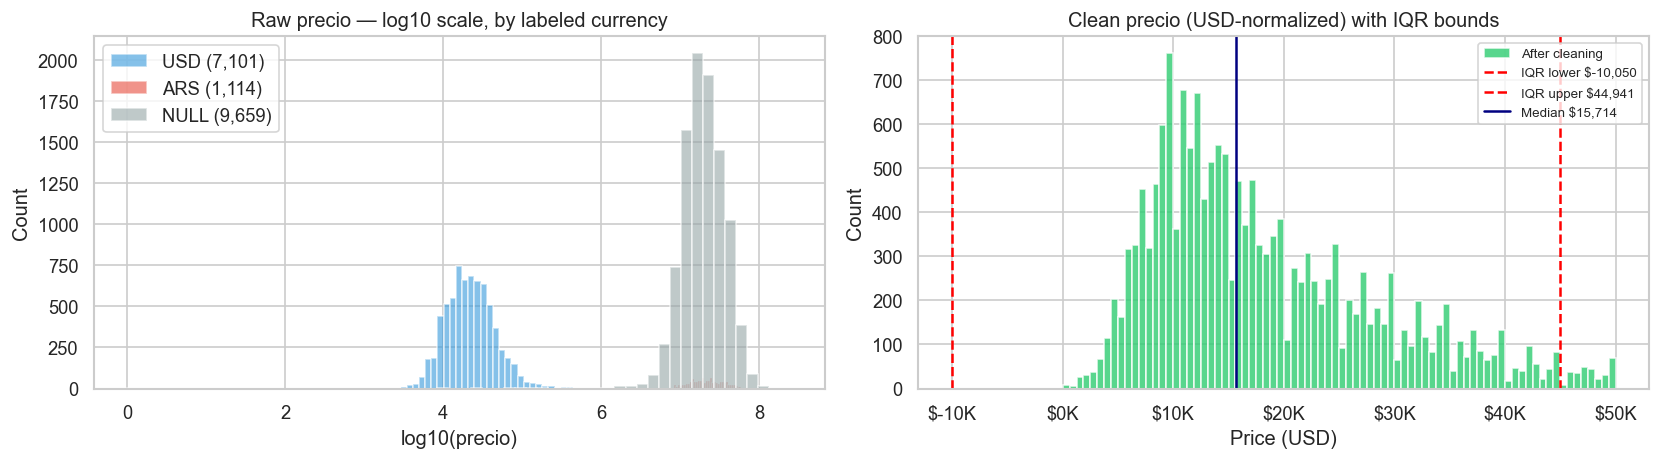

IQR bounds: $-10,050 – $44,941  |  Median: $15,714


In [5]:
# Price histogram on log scale — raw, split by currency
df_plot = df_raw.dropna(subset=['precio']).copy()
df_plot['currency_group'] = df_plot['moneda'].fillna('NULL')

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 4))

# Left: raw price distribution by currency group
for group, color in [('USD', '#3498db'), ('ARS', '#e74c3c'), ('NULL', '#95a5a6')]:
    subset = df_plot[df_plot['currency_group'] == group]['precio']
    if len(subset):
        axes[0].hist(np.log10(subset.clip(lower=1)), bins=60, alpha=0.6, label=f'{group} ({len(subset):,})', color=color)
axes[0].set_title('Raw precio — log10 scale, by labeled currency')
axes[0].set_xlabel('log10(precio)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: clean USD-normalized prices with IQR bounds
prices_clean = df_clean['precio']
q1, q3 = prices_clean.quantile(0.25), prices_clean.quantile(0.75)
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr

axes[1].hist(prices_clean, bins=80, color='#2ecc71', alpha=0.8, label='After cleaning')
axes[1].axvline(lower_bound, color='red', linestyle='--', label=f'IQR lower ${lower_bound:,.0f}')
axes[1].axvline(upper_bound, color='red', linestyle='--', label=f'IQR upper ${upper_bound:,.0f}')
axes[1].axvline(prices_clean.median(), color='navy', linestyle='-', label=f'Median ${prices_clean.median():,.0f}')
axes[1].set_title('Clean precio (USD-normalized) with IQR bounds')
axes[1].set_xlabel('Price (USD)')
axes[1].set_ylabel('Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f'IQR bounds: ${lower_bound:,.0f} – ${upper_bound:,.0f}  |  Median: ${prices_clean.median():,.0f}')

## 3. Numeric Feature Distributions

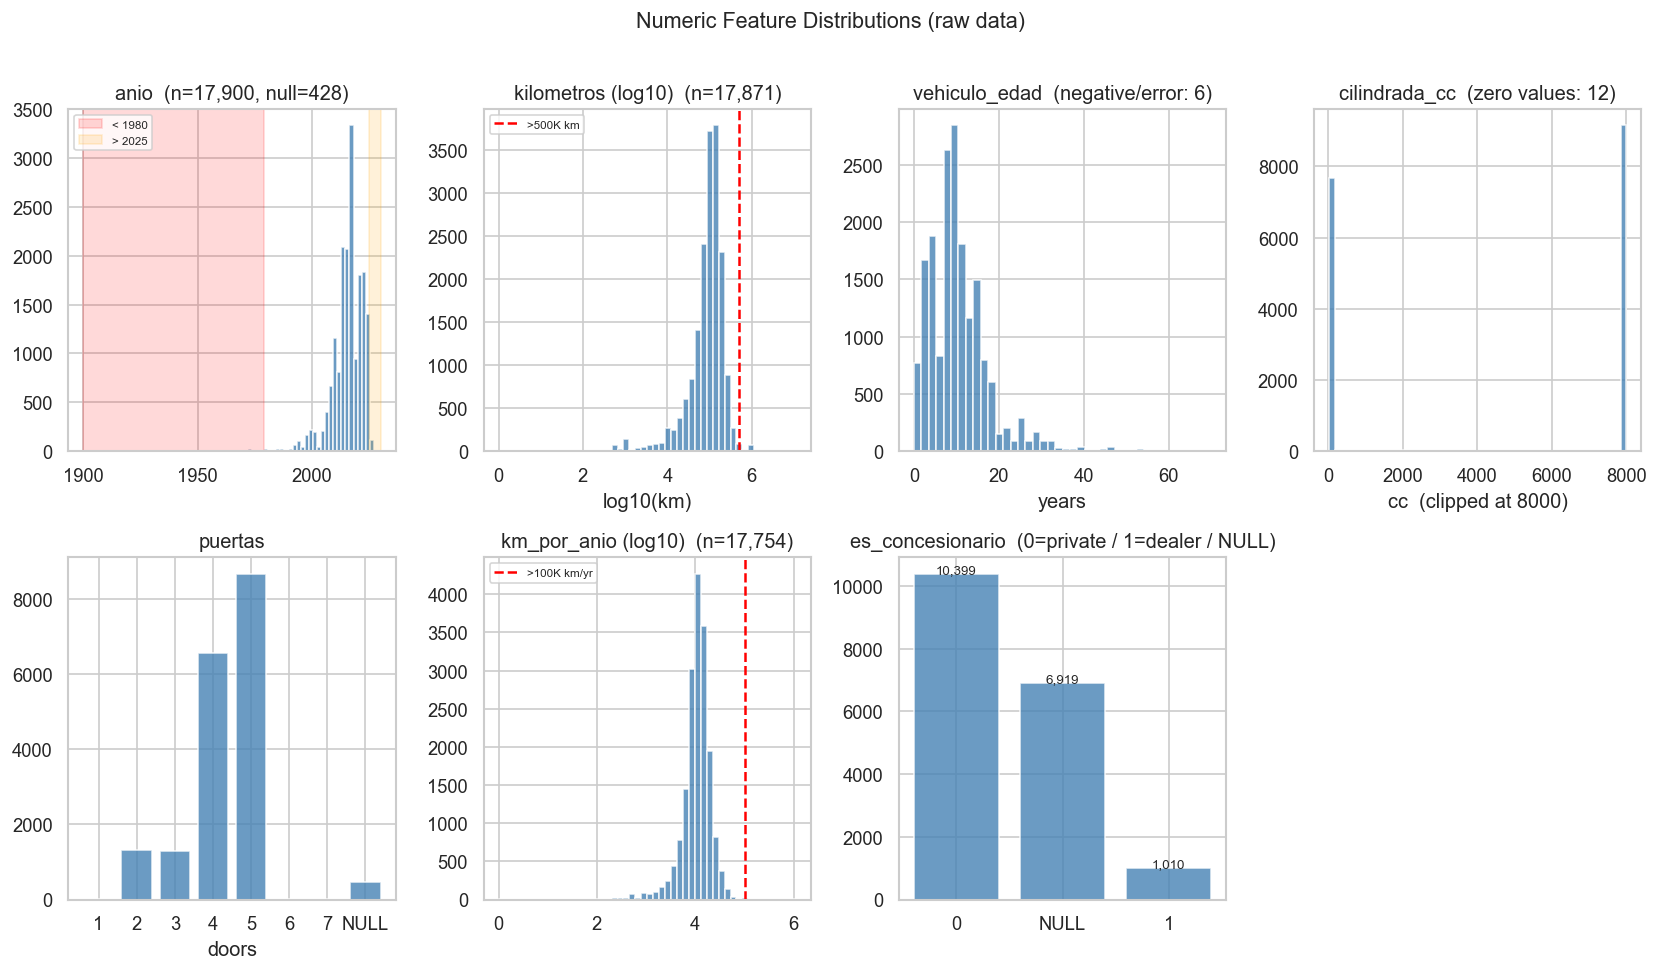

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(FIG_W, 8))
axes = axes.flatten()

# anio
ax = axes[0]
data = df_raw['anio'].dropna()
ax.hist(data, bins=40, color='steelblue', alpha=0.8)
ax.axvspan(1900, 1979, alpha=0.15, color='red', label='< 1980')
ax.axvspan(2025, 2030, alpha=0.15, color='orange', label='> 2025')
ax.set_title(f'anio  (n={len(data):,}, null={df_raw["anio"].isnull().sum()})')
ax.legend(fontsize=7)

# kilometros — log scale
ax = axes[1]
data = df_raw['kilometros'].dropna().clip(lower=1)
ax.hist(np.log10(data), bins=50, color='steelblue', alpha=0.8)
ax.axvline(np.log10(500_000), color='red', linestyle='--', label='>500K km')
ax.set_title(f'kilometros (log10)  (n={len(data):,})')
ax.set_xlabel('log10(km)')
ax.legend(fontsize=7)

# vehiculo_edad
ax = axes[2]
data = df_raw['vehiculo_edad'].dropna()
neg_count = int((data < 0).sum())
ax.hist(data.clip(lower=0), bins=40, color='steelblue', alpha=0.8)
ax.set_title(f'vehiculo_edad  (negative/error: {neg_count})')
ax.set_xlabel('years')

# cilindrada_cc
ax = axes[3]
data = df_raw['cilindrada_cc'].dropna()
zero_count = int((data == 0).sum())
ax.hist(data[data > 0].clip(upper=8000), bins=50, color='steelblue', alpha=0.8)
ax.set_title(f'cilindrada_cc  (zero values: {zero_count})')
ax.set_xlabel('cc  (clipped at 8000)')

# puertas — explicit label handling for NaN
ax = axes[4]
vc = df_raw['puertas'].value_counts(dropna=False).sort_index()
labels = [str(int(x)) if pd.notna(x) else 'NULL' for x in vc.index]
ax.bar(range(len(labels)), vc.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_title('puertas')
ax.set_xlabel('doors')

# km_por_anio — log scale
ax = axes[5]
data = df_raw['km_por_anio'].dropna().clip(lower=1)
ax.hist(np.log10(data), bins=50, color='steelblue', alpha=0.8)
ax.axvline(np.log10(100_000), color='red', linestyle='--', label='>100K km/yr')
ax.set_title(f'km_por_anio (log10)  (n={len(data):,})')
ax.legend(fontsize=7)

# es_concesionario — explicit label handling for NaN
ax = axes[6]
vc = df_raw['es_concesionario'].value_counts(dropna=False)
labels = [str(int(x)) if pd.notna(x) else 'NULL' for x in vc.index]
ax.bar(range(len(labels)), vc.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
for i, val in enumerate(vc.values):
    ax.text(i, val + 20, f'{val:,}', ha='center', fontsize=8)
ax.set_title('es_concesionario  (0=private / 1=dealer / NULL)')

axes[7].axis('off')

plt.suptitle('Numeric Feature Distributions (raw data)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 4. Categorical Feature Distributions

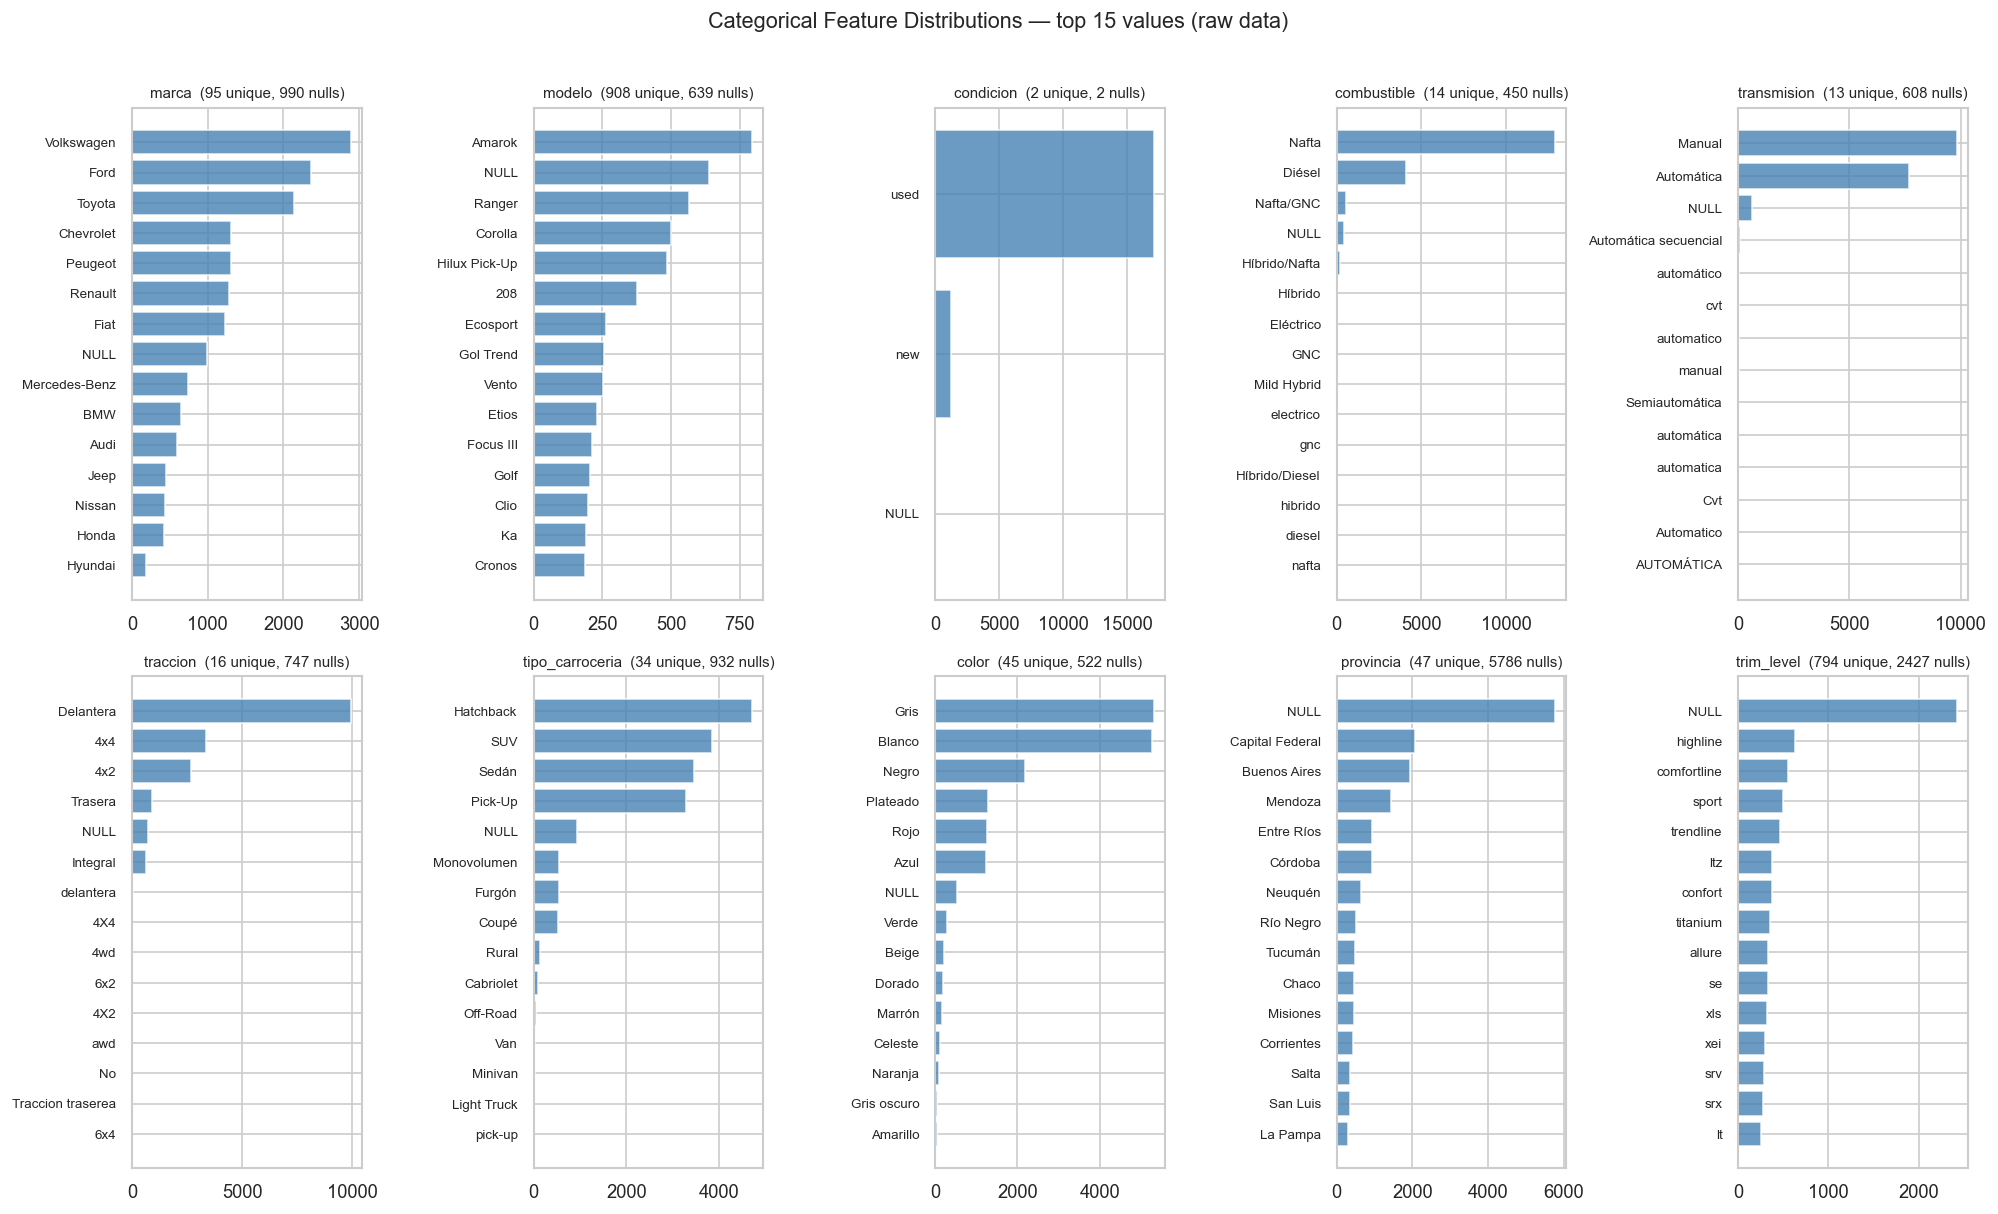

In [7]:
def plot_cat(ax, col, df, top_n=TOP_N, title=None):
    vc = df[col].value_counts(dropna=False).head(top_n)
    labels = [str(x) if x is not None and str(x) != 'nan' else 'NULL' for x in vc.index]
    ax.barh(labels[::-1], vc.values[::-1], color='steelblue', alpha=0.8)
    total = df[col].isnull().sum()
    n_unique = df[col].nunique()
    ax.set_title(title or f'{col}  ({n_unique} unique, {total} nulls)', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

fig, axes = plt.subplots(2, 5, figsize=(FIG_W * 1.2, 10))
cats = CATEGORICAL_FEATURES  # 10 features
for ax, col in zip(axes.flatten(), cats):
    plot_cat(ax, col, df_raw)

plt.suptitle(f'Categorical Feature Distributions — top {TOP_N} values (raw data)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 5. Price by Feature (Bivariate)

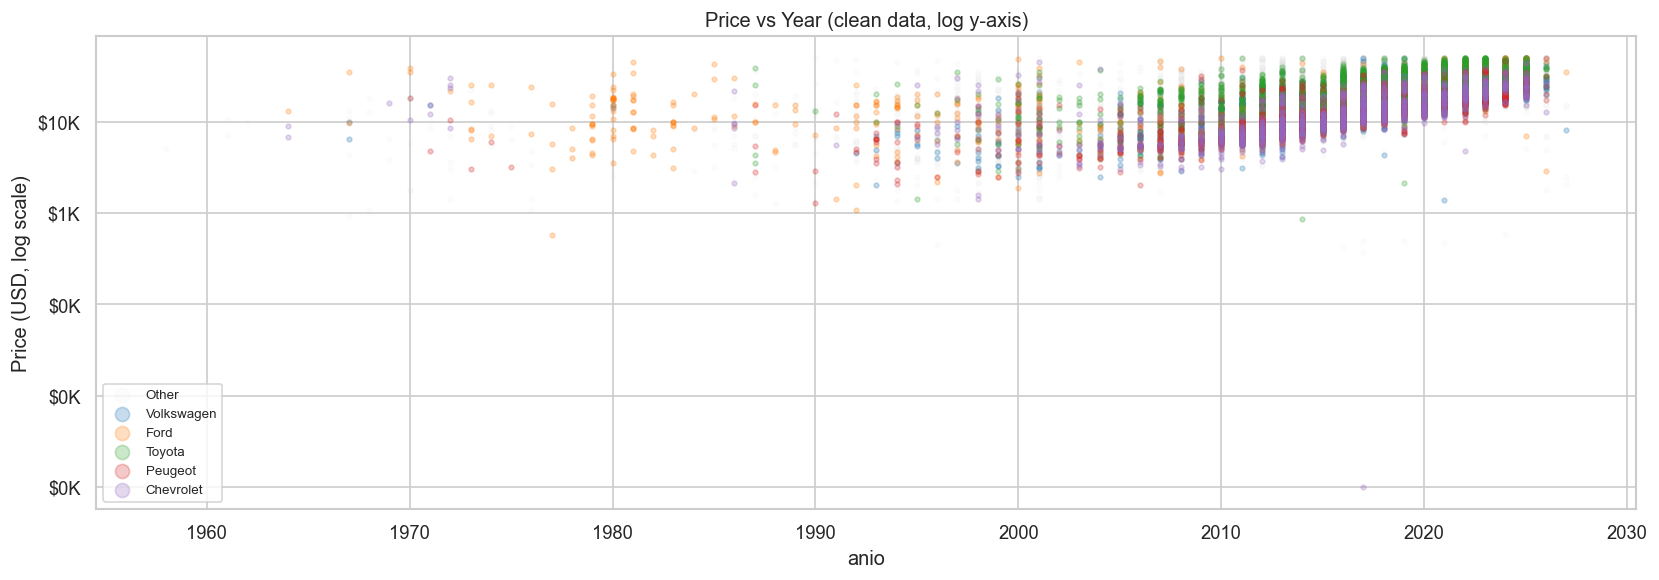

In [8]:
# Price vs anio — scatter, colored by top-5 marca
top_marcas = df_clean['marca'].value_counts().head(5).index.tolist()
palette = sns.color_palette('tab10', len(top_marcas) + 1)

fig, ax = plt.subplots(figsize=(FIG_W, 5))
other = df_clean[~df_clean['marca'].isin(top_marcas)]
ax.scatter(other['anio'], other['precio'], alpha=0.05, color='lightgrey', s=8, label='Other')
for i, marca in enumerate(top_marcas):
    sub = df_clean[df_clean['marca'] == marca]
    ax.scatter(sub['anio'], sub['precio'], alpha=0.25, s=8, color=palette[i], label=marca)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('Price vs Year (clean data, log y-axis)')
ax.set_xlabel('anio')
ax.set_ylabel('Price (USD, log scale)')
ax.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

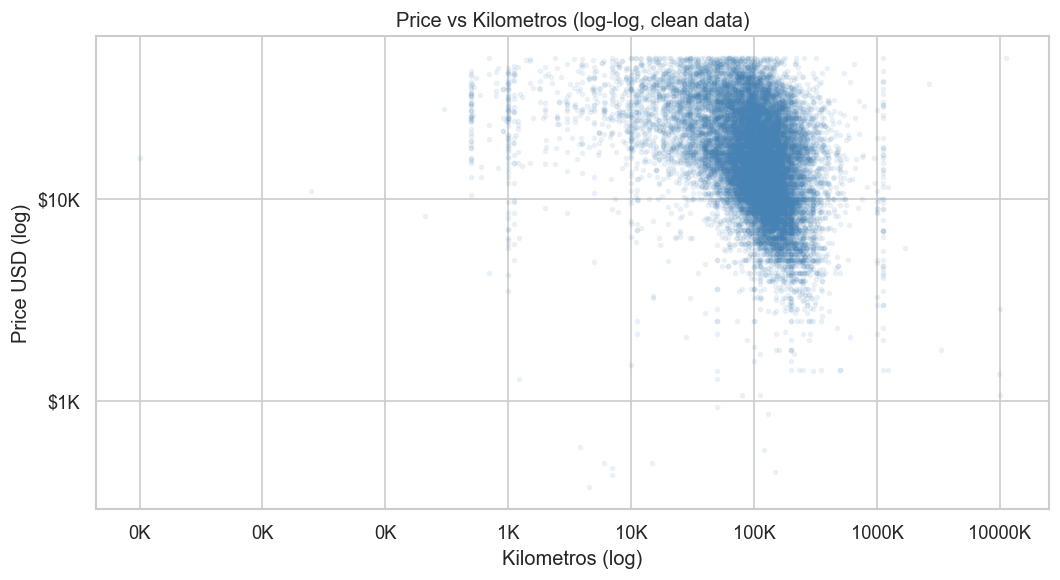

In [9]:
# Price vs kilometros — log-log
sub = df_clean.dropna(subset=['kilometros'])
sub = sub[sub['kilometros'] > 0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sub['kilometros'], sub['precio'], alpha=0.08, s=6, color='steelblue')
ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('Price vs Kilometros (log-log, clean data)')
ax.set_xlabel('Kilometros (log)')
ax.set_ylabel('Price USD (log)')
plt.tight_layout()
plt.show()

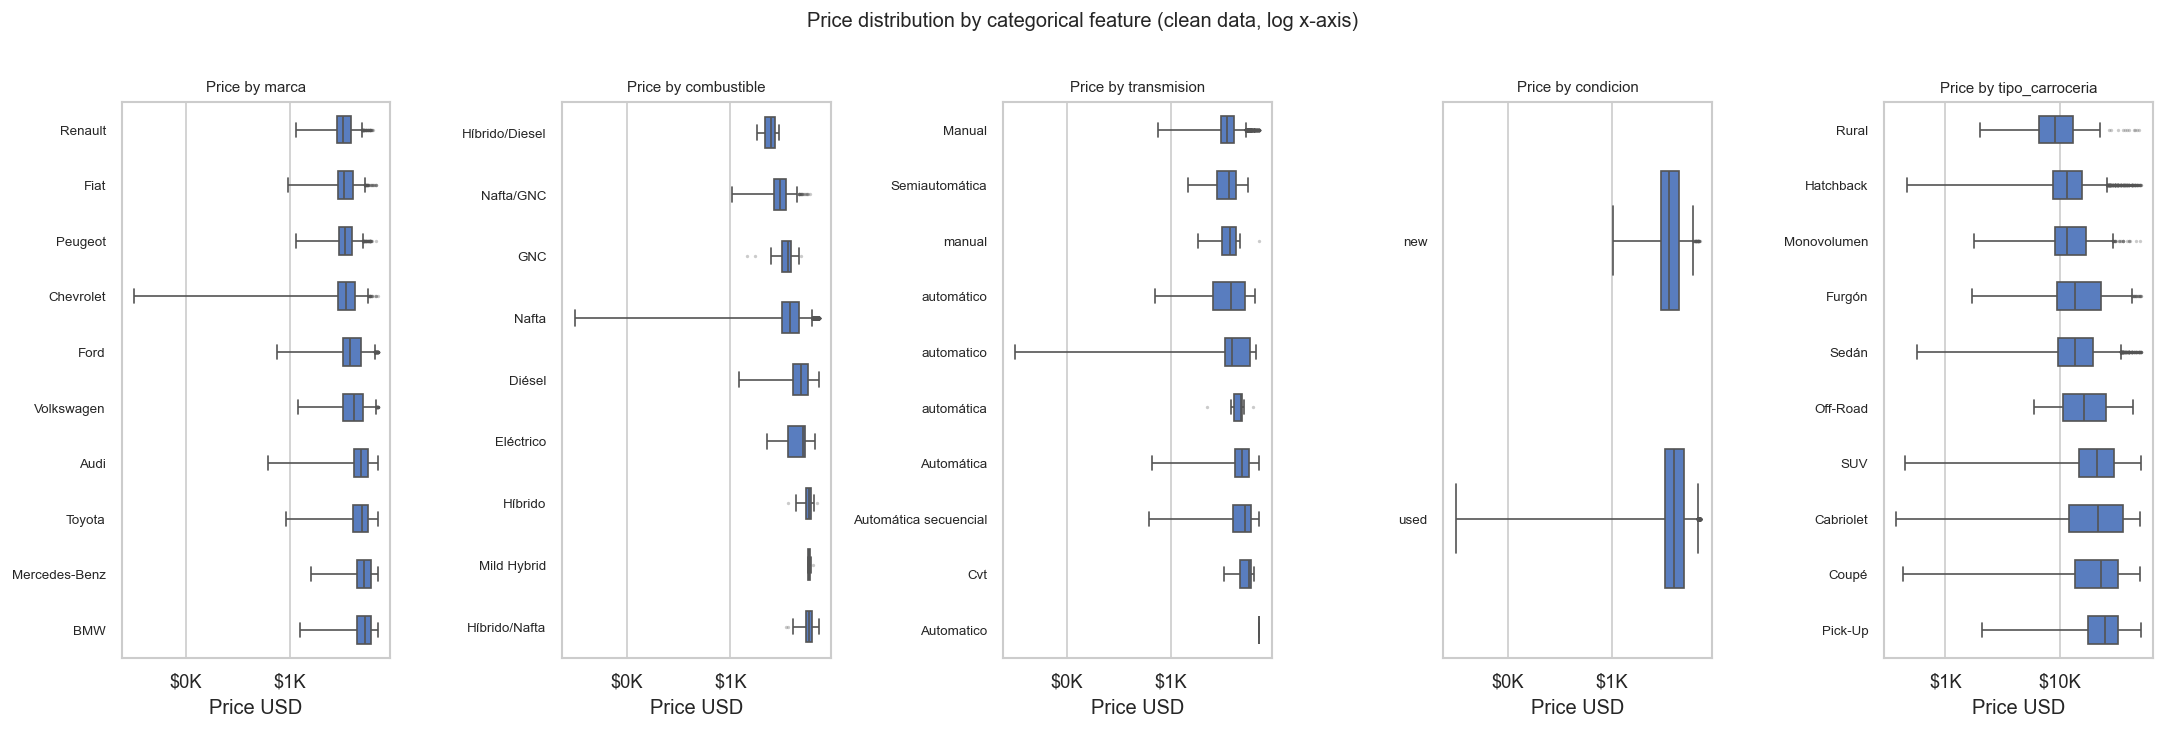

In [10]:
# Box plots: price by categorical features
def price_boxplot(ax, col, df, top_n=10, title=None, log_x=True):
    top = df[col].value_counts().head(top_n).index
    sub = df[df[col].isin(top)].copy()
    order = sub.groupby(col)['precio'].median().sort_values().index
    sns.boxplot(data=sub, x='precio', y=col, order=order, ax=ax,
                flierprops=dict(marker='.', markersize=2, alpha=0.3), width=0.5)
    if log_x:
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.set_title(title or f'Price by {col}', fontsize=9)
    ax.set_xlabel('Price USD')
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=8)

box_cols = ['marca', 'combustible', 'transmision', 'condicion', 'tipo_carroceria']
fig, axes = plt.subplots(1, len(box_cols), figsize=(FIG_W * 1.3, 6))
for ax, col in zip(axes, box_cols):
    price_boxplot(ax, col, df_clean)

plt.suptitle('Price distribution by categorical feature (clean data, log x-axis)', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 6. Data Quality Summary

In [11]:
# Null % table (all columns, sorted)
print('=== Null % (all columns, sorted) ===')
null_pct = (df_raw.isnull().mean() * 100).sort_values(ascending=False).round(1)
print(null_pct.to_string())

print('\n=== Cardinality of categorical features ===')
card = pd.DataFrame({
    'unique_values': [df_raw[c].nunique() for c in CATEGORICAL_FEATURES],
    'null_%': [(df_raw[c].isnull().mean() * 100).round(1) for c in CATEGORICAL_FEATURES],
    'top_value': [df_raw[c].value_counts().index[0] if df_raw[c].notna().any() else 'N/A' for c in CATEGORICAL_FEATURES],
    'top_value_%': [(df_raw[c].value_counts(normalize=True).iloc[0] * 100).round(1) if df_raw[c].notna().any() else 0 for c in CATEGORICAL_FEATURES],
}, index=CATEGORICAL_FEATURES).sort_values('unique_values', ascending=False)
print(card.to_string())

=== Null % (all columns, sorted) ===
moneda              55.2
es_concesionario    37.8
provincia           31.6
trim_level          13.2
cilindrada_cc        7.3
marca                5.4
tipo_carroceria      5.1
traccion             4.1
modelo               3.5
transmision          3.3
km_por_anio          3.1
color                2.8
puertas              2.6
version              2.6
kilometros           2.5
precio               2.5
combustible          2.5
vehiculo_edad        2.3
anio                 2.3
condicion            0.0
item_id              0.0
source_url           0.0
scraped_at           0.0
created_at           0.0
id                   0.0

=== Cardinality of categorical features ===
                 unique_values  null_%        top_value  top_value_%
modelo                     908     3.5           Amarok          4.5
trim_level                 794    13.2         highline          3.9
marca                       95     5.4       Volkswagen         16.7
provincia        

## Findings & Preprocessing Improvements

*(Fill in after running the notebook — note specific issues observed per feature.)*

### Observed Issues
- `moneda`: ~55% NULL — currency inferred from price magnitude in `train.py`. Consider adding explicit magnitude-based rule directly in the scraper/parser.
- `cilindrada_cc = 0`: Should be treated as NaN. Add `df.loc[df['cilindrada_cc'] == 0, 'cilindrada_cc'] = np.nan` in `load_data()`.
- `vehiculo_edad < 0`: Parsing error rows (−1). Should be capped/nulled before training. Add `df.loc[df['vehiculo_edad'] < 0, 'vehiculo_edad'] = np.nan` in `load_data()`.
- `trim_level`: 13% NULL and 794 unique values. Consider grouping rare trims (< N occurrences) into `'Other'` to reduce cardinality.
- `modelo`: 908 unique values. Verify no duplicate spellings (e.g. `'208'` vs `'Peugeot 208'`).
- `km_por_anio`: Very high values (>100K/yr) are mathematically valid but likely data errors. Consider capping.

### Suggested `load_data()` Additions
```python
# Fix zero cilindrada
df.loc[df['cilindrada_cc'] == 0, 'cilindrada_cc'] = np.nan

# Fix negative vehiculo_edad
df.loc[df['vehiculo_edad'] < 0, 'vehiculo_edad'] = np.nan

# Cap extreme km_por_anio
df.loc[df['km_por_anio'] > 100_000, 'km_por_anio'] = np.nan
```